## Analyse and filter modisco patterns

In [1]:
import pandas as pd
import polars as pl
from polars import col as c
import os

import pandas as pd
from bs4 import BeautifulSoup

from modiscolite.report import *

import torch
from matplotlib import pyplot as plt

import sys
sys.path.append("/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/arch")
from arch_enhancer import build_enhancer

from scipy.stats import false_discovery_control
from memelite import tomtom

from tangermeme.plot import plot_logo
from matplotlib import pyplot as plt

from torch.nn import Softmax
import numpy as np

In [2]:
def df_to_html(df,name,results_dir):
    df.to_html(
    open(os.path.join(results_dir, f'{name}.html'), 'w'),
        escape=False,
        formatters=dict(modisco_cwm_fwd=path_to_image_html,
                        modisco_cwm_rev=path_to_image_html, 
                        match0_logo=path_to_image_html,
                        match1_logo=path_to_image_html, 
                        match2_logo=path_to_image_html), 
        index=False)

def df_to_html_kernels(df,name,results_dir):
    df.to_html(
    open(os.path.join(results_dir, f'{name}.html'), 'w'),
        escape=False,
        formatters=dict(modisco_cwm_fwd=path_to_image_html,
                        modisco_cwm_rev=path_to_image_html, 
                        match0_logo=path_to_image_html,
                        match1_logo=path_to_image_html, 
                        match2_logo=path_to_image_html,
                        kernel_pattern=path_to_image_html
                       ), 
        index=False)
    
def df_to_html_tn5(df,name,results_dir):
    df.to_html(
    open(os.path.join(results_dir, f'{name}.html'), 'w'),
        escape=False,
        formatters=dict(modisco_cwm_fwd=path_to_image_html,
                        modisco_cwm_rev=path_to_image_html, 
                        match0_logo=path_to_image_html,
                        match1_logo=path_to_image_html, 
                        match2_logo=path_to_image_html,
                        kernel_pattern=path_to_image_html,
                        Tn5_pattern=path_to_image_html
                       ), 
        index=False)

def trim_pattern(pat,trim_threshold=0.3):
    score = np.sum(np.abs(pat.T), axis=1)
    trim_thresh = np.max(score) * trim_threshold  # Cut off anything less than 30% of max score
    pass_inds = np.where(score >= trim_thresh)[0]
    trimmed = pat.T[np.min(pass_inds): np.max(pass_inds) + 1].T
    return trimmed

def patterns_from_patnames(patternname, h5file):
    with h5py.File(h5file, 'r') as file:
        
        pattern_group = patternname.split(".")[0]
        pattern_id = patternname.split(".")[1]
        pattern = file[pattern_group][pattern_id]['hypothetical_contribs'][:].T

        return pattern

In [20]:
for k in motif_dict.keys():
    if "TWIST" in k:
        print(k)

MA1123.3 TWIST1


In [33]:
motif_dict["MA0867.3 SOX4"].flip(dims=(0,1))

tensor([[2.4241e-02, 1.2302e-02, 3.2098e-01, 0.0000e+00, 0.0000e+00, 5.8390e-03,
         1.6100e-03, 4.7830e-02],
        [4.8607e-01, 8.2733e-01, 5.9020e-03, 1.9650e-03, 1.0740e-03, 6.5460e-03,
         0.0000e+00, 2.2717e-01],
        [1.9811e-01, 9.4860e-03, 1.4166e-02, 1.0720e-03, 1.7900e-04, 9.8762e-01,
         0.0000e+00, 1.0554e-01],
        [2.9158e-01, 1.5088e-01, 6.5895e-01, 9.9696e-01, 9.9875e-01, 0.0000e+00,
         9.9839e-01, 6.1947e-01]], dtype=torch.float64)

Text(0, 0.5, 'Nucleotide probability')

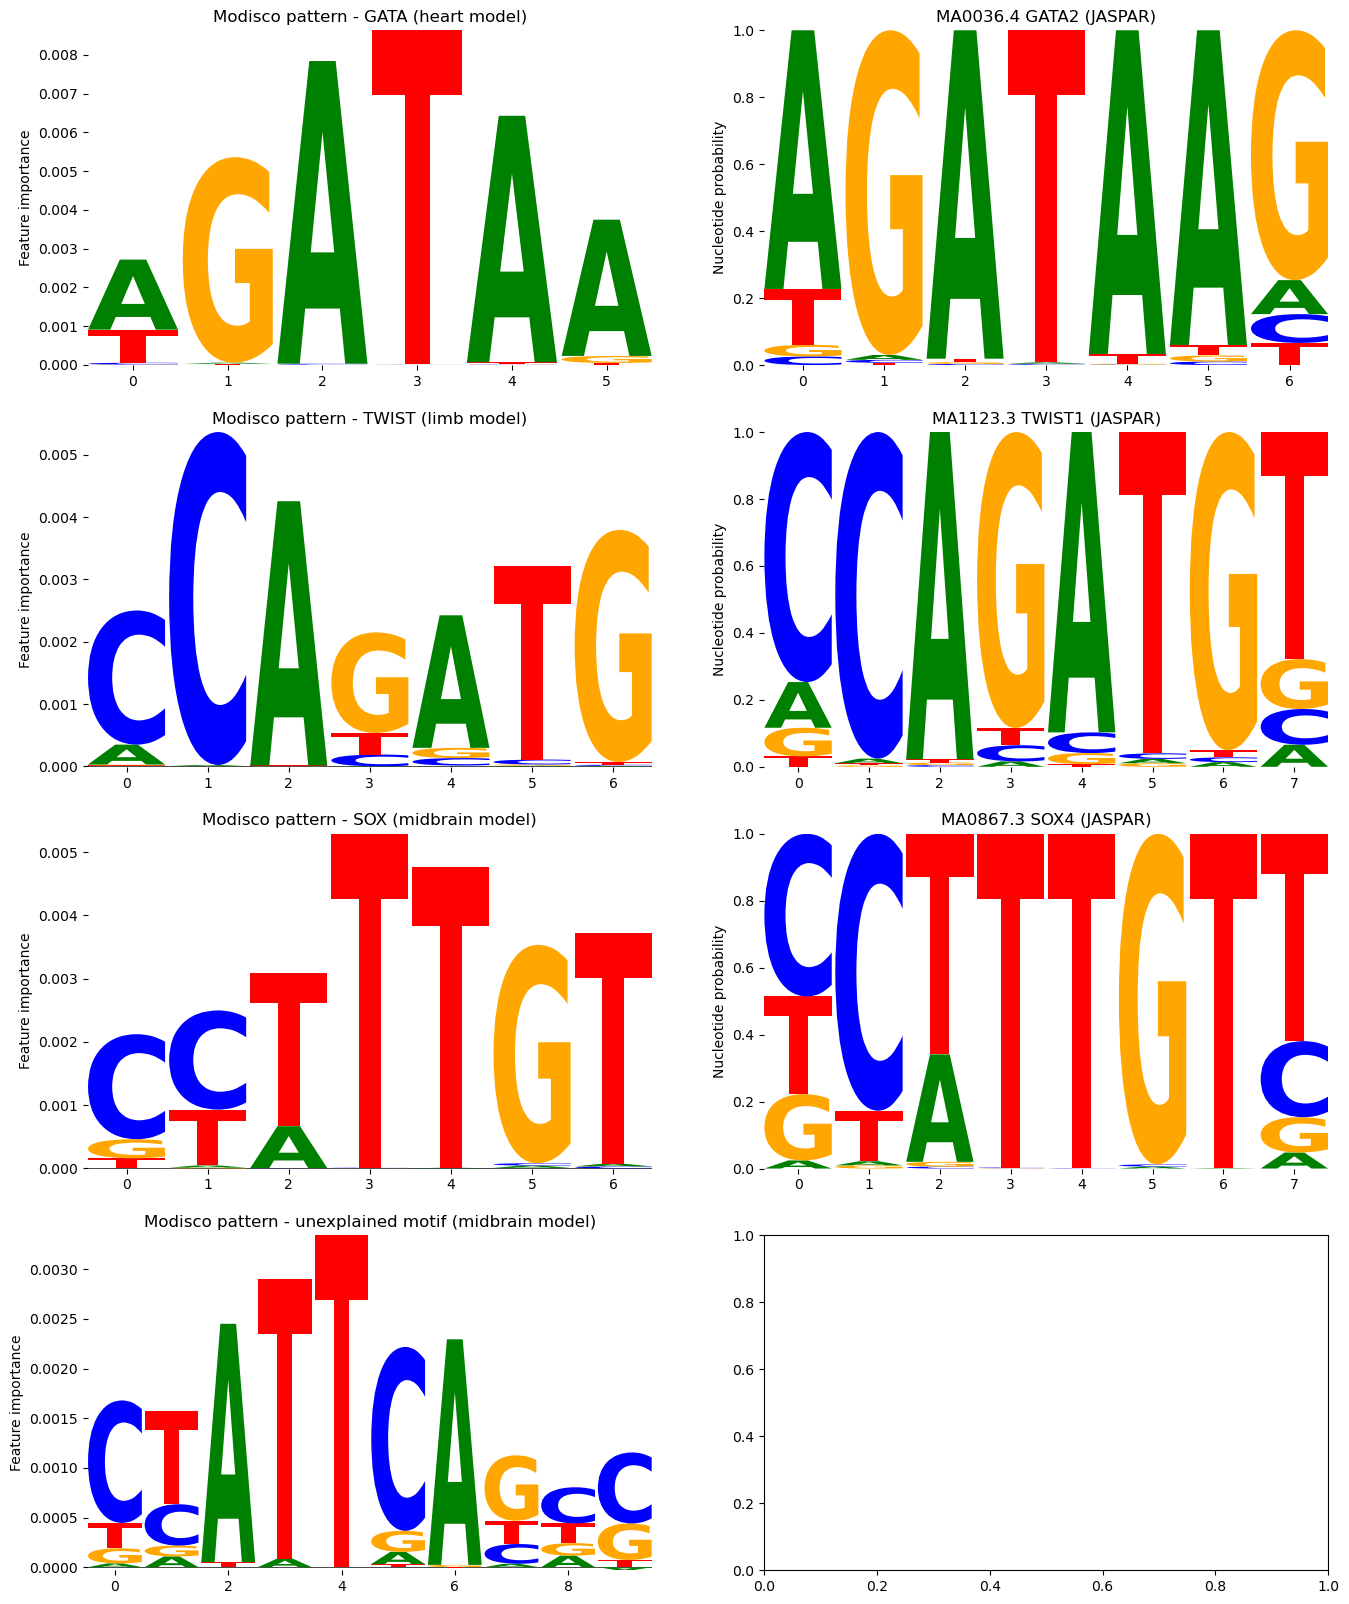

In [38]:
%matplotlib inline

fig,ax = plt.subplots(nrows=4,ncols=2, figsize=(8*2,5*4))

tissue="heart" 
modeltype="VISTA"
modisco_h5_file = f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/{tissue}/{modeltype}_models/fold01_rep1_modisco.h5"
gata_pattern = trim_pattern(patterns_from_patnames("pos_patterns.pattern_0", modisco_h5_file))
plot_logo(gata_pattern,ax=ax[0,0])
ax[0,0].set_title("Modisco pattern - GATA (heart model)")
ax[0,0].set_ylabel("Feature importance")

tissue="limb" 
modeltype="VISTA"
modisco_h5_file = f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/{tissue}/{modeltype}_models/fold01_rep1_modisco.h5"
twist_pattern = trim_pattern(patterns_from_patnames("pos_patterns.pattern_0", modisco_h5_file))
plot_logo(twist_pattern,ax=ax[1,0])
ax[1,0].set_title("Modisco pattern - TWIST (limb model)")
ax[1,0].set_ylabel("Feature importance")

tissue="midbrain" 
modeltype="VISTA"
modisco_h5_file = f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/{tissue}/{modeltype}_models/fold01_rep1_modisco.h5"
twist_pattern = trim_pattern(patterns_from_patnames("pos_patterns.pattern_0", modisco_h5_file))
novel_pattern = trim_pattern(patterns_from_patnames("pos_patterns.pattern_3", modisco_h5_file))

plot_logo(twist_pattern,ax=ax[2,0])
ax[2,0].set_title("Modisco pattern - SOX (midbrain model)")
ax[2,0].set_ylabel("Feature importance")

plot_logo(novel_pattern,ax=ax[3,0])
ax[3,0].set_title("Modisco pattern - unexplained motif (midbrain model)")
ax[3,0].set_ylabel("Feature importance")


jaspar_file="/groups/stark/nikolaus.mandlburger/Projects/blastoid_project/res/accessibility_models_and_data/TE_total/dataselection_3/feature_attributions/trainingruns_280524/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt"
motif_dict = read_meme(jaspar_file)

plot_logo(motif_dict["MA0036.4 GATA2"].flip(dims=(0,1)),ax=ax[0,1])
ax[0,1].set_title("MA0036.4 GATA2 (JASPAR)")
ax[0,1].set_ylabel("Nucleotide probability")

plot_logo(motif_dict["MA1123.3 TWIST1"],ax=ax[1,1])
ax[1,1].set_title("MA1123.3 TWIST1 (JASPAR)")
ax[1,1].set_ylabel("Nucleotide probability")

plot_logo(motif_dict["MA0867.3 SOX4"].flip(dims=(0,1)),ax=ax[2,1])
ax[2,1].set_title("MA0867.3 SOX4 (JASPAR)")
ax[2,1].set_ylabel("Nucleotide probability")



In [39]:
fig.savefig(f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/src/modico_analysis/example_motifs.pdf",bbox_inches="tight")

In [13]:
!pwd

/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/src/modico_analysis


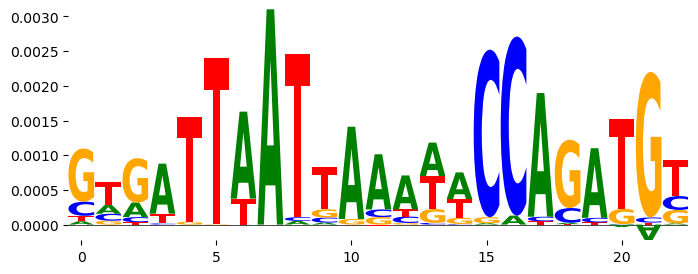

In [14]:

fig,ax = plt.subplots(figsize=(8,3))
plot_logo(pat,ax=ax)
fig.savefig(f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/src/modico_analysis/limbpos_patterns.pattern_25.pdf",bbox_inches="tight")

In [61]:

tissue="midbrain" 
modeltype="VISTA"
pattern_category = "no_sign_jaspar_hits" #"sign_jaspar_hits" "no_sign_jaspar_hits"
jasparmatch_q_threshold=0.05
t=10 #softmax temperature

jaspar_file="/groups/stark/nikolaus.mandlburger/Projects/blastoid_project/res/accessibility_models_and_data/TE_total/dataselection_3/feature_attributions/trainingruns_280524/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt"
weights_dir = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/weight/model1_bulkATAC_tsx3Aug_2xBal_noW/"
architectures_dir = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/arch/"
fold = "fold01"
rep="rep1"


modisco_h5_file = f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/{tissue}/{modeltype}_models/fold01_rep1_modisco.h5"
results_supdir="/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/"
results_dir=f"{results_supdir}/{tissue}/{modeltype}_models/fold01_rep1_modisco/"

###############################################################
#read in html table, replacing the images with their filepaths
###############################################################

htmlreport_file=f"{results_dir}/{tissue}_{modeltype}_motifs_tfnames.html"
with open(htmlreport_file) as f:
    html = f.read()
# Parse with pandas
df = pd.read_html(html)[0]
# Parse with BeautifulSoup
soup = BeautifulSoup(html, "html.parser")
table = soup.find("table")
rows = []
for tr in table.find_all("tr"):
    cells = []
    for td in tr.find_all(["td", "th"]):
        img = td.find("img")
        if img and img.has_attr("src"):
            cells.append(img["src"])
        else:
            cells.append(td.get_text(strip=True))
    rows.append(cells)
# First row = header
report_df = pd.DataFrame(rows[1:], columns=rows[0])

#Filter results in desired way
report_df = report_df.loc[report_df["pattern"].str.startswith("pos")]
report_df["qval0"] = report_df["qval0"].astype(float)

if pattern_category=="sign_jaspar_hits":
    report_df = report_df.loc[report_df["qval0"]<jasparmatch_q_threshold]
elif pattern_category=="no_sign_jaspar_hits":
    report_df = report_df.loc[report_df["qval0"]>jasparmatch_q_threshold]

df = report_df

###############################################################
#Extract modisco patterns from modisc_h5 file
###############################################################

patterns = [trim_pattern(patterns_from_patnames(pn, modisco_h5_file)) for pn in df["pattern"]]
patterns = [np.where(p<0,0,p) for p in patterns]
patterns = [(p*7)/p.sum() for p in patterns]

###############################################################
#Retrieve kernel weights
###############################################################

#Load model

if modeltype=="ATAC":
    modeltype_for_weightsloading="access"
elif modeltype=="VISTA":
    modeltype_for_weightsloading="enhancer"

weights_path = f"{weights_dir}/{tissue}/results_{fold}_{tissue}_DeepSTARR2_{rep}/{modeltype_for_weightsloading}_model_state_dict.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_enhancer().to(device)
state = torch.load(weights_path, map_location=device)

if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
_=model.eval()

#Actual kernel weight retrieval

conv1_kernelweights_list = list(model.conv1[0].weight.detach().numpy())
conv1_kernelweights_list = [torch.tensor(k) for k in conv1_kernelweights_list]

#Softmaxxing of kernel weights
softmax = Softmax(dim=0)
conv1_kernelweights_softmaxxed_list = [softmax(k*t) for k in conv1_kernelweights_list]

#############################
#Matching patterns to kernels
#############################

tomtom_matches = tomtom(patterns,conv1_kernelweights_softmaxxed_list, n_target_bins=None)
pvals,scores,_,_,idxs = tomtom_matches

pcorr = np.ones_like(pvals)
for i,row in enumerate(pvals):
    row_corr = false_discovery_control(row)
    pcorr[i,:]=row_corr

    
#############################
#Saving kernel plots as pngs (for later loading in html)
#############################
    
kernel_igm_savedir = f"{results_dir}/kernel_img/"
os.makedirs(kernel_igm_savedir, exist_ok=True)

img_filenames = []
kernelnames = []
q_vals = []

for i,idx in enumerate(pvals.argmin(axis=1)):

    #fig,ax = plt.subplots(figsize=(10,2))
    #plot_logo(conv1_kernelweights_softmaxxed_list[idx],ax=ax)
    #fig.savefig(f"{kernel_igm_savedir}/kernel_{idx}_{df['pattern'].iloc[i]}.png",bbox_inches="tight")
    
    img_filenames.append(f"./kernel_img/kernel_{idx}_{df['pattern'].iloc[i]}.png")
    kernelnames.append(f"kernel_{idx}")
    q_vals.append(f"{pcorr[i,idx]:.5f}")

#df["kernel_nr"] = kernelnames
df["kernel_match_qval"]  = q_vals
df["kernel_pattern"] = img_filenames


##################################
#Saving modified dataframe to html
##################################

#df_to_html_kernels(df,f"{tissue}_{modeltype}_patterns_{pattern_category}_q{jasparmatch_q_threshold}",results_dir)

/tmp/ipykernel_69144/4262649753.py:26: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]
/tmp/ipykernel_69144/4262649753.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any 

In [64]:
df.shape

(21, 15)

In [76]:

tissue="midbrain" 
modeltype="VISTA"
pattern_category = "sign_jaspar_hits" #"sign_jaspar_hits" "no_sign_jaspar_hits"
jasparmatch_q_threshold=0.05
t=10 #softmax temperature

#jaspar_file="/groups/stark/nikolaus.mandlburger/Projects/blastoid_project/res/accessibility_models_and_data/TE_total/dataselection_3/feature_attributions/trainingruns_280524/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt"
weights_dir = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/weight/model1_bulkATAC_tsx3Aug_2xBal_noW/"
architectures_dir = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/arch/"
fold = "fold01"
rep="rep1"


modisco_h5_file = f"/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/{tissue}/{modeltype}_models/fold01_rep1_modisco.h5"
results_supdir="/groups/stark/nikolaus.mandlburger/Projects/shenzhi_revisions/res/modico_analysis/"
results_dir=f"{results_supdir}/{tissue}/{modeltype}_models/fold01_rep1_modisco_v10nr_clust_public/"

###############################################################
#read in html table, replacing the images with their filepaths
###############################################################

htmlreport_file=f"{results_dir}/motifs.html"
with open(htmlreport_file) as f:
    html = f.read()
# Parse with pandas
df = pd.read_html(html)[0]
# Parse with BeautifulSoup
soup = BeautifulSoup(html, "html.parser")
table = soup.find("table")
rows = []
for tr in table.find_all("tr"):
    cells = []
    for td in tr.find_all(["td", "th"]):
        img = td.find("img")
        if img and img.has_attr("src"):
            cells.append(img["src"])
        else:
            cells.append(td.get_text(strip=True))
    rows.append(cells)
# First row = header
report_df = pd.DataFrame(rows[1:], columns=rows[0])

#Filter results in desired way
report_df = report_df.loc[report_df["pattern"].str.startswith("pos")]
report_df["qval0"] = report_df["qval0"].astype(float)

if pattern_category=="sign_jaspar_hits":
    report_df = report_df.loc[report_df["qval0"]<jasparmatch_q_threshold]
elif pattern_category=="no_sign_jaspar_hits":
    report_df = report_df.loc[report_df["qval0"]>jasparmatch_q_threshold]

df = report_df

###############################################################
#Extract modisco patterns from modisc_h5 file
###############################################################

patterns = [trim_pattern(patterns_from_patnames(pn, modisco_h5_file)) for pn in df["pattern"]]
patterns = [np.where(p<0,0,p) for p in patterns]
patterns = [(p*7)/p.sum() for p in patterns]

###############################################################
#Retrieve kernel weights
###############################################################

#Load model

if modeltype=="ATAC":
    modeltype_for_weightsloading="access"
elif modeltype=="VISTA":
    modeltype_for_weightsloading="enhancer"

weights_path = f"{weights_dir}/{tissue}/results_{fold}_{tissue}_DeepSTARR2_{rep}/{modeltype_for_weightsloading}_model_state_dict.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_enhancer().to(device)
state = torch.load(weights_path, map_location=device)

if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
_=model.eval()

#Actual kernel weight retrieval

conv1_kernelweights_list = list(model.conv1[0].weight.detach().numpy())
conv1_kernelweights_list = [torch.tensor(k) for k in conv1_kernelweights_list]

#Softmaxxing of kernel weights
softmax = Softmax(dim=0)
conv1_kernelweights_softmaxxed_list = [softmax(k*t) for k in conv1_kernelweights_list]

#############################
#Matching patterns to kernels
#############################

tomtom_matches = tomtom(patterns,conv1_kernelweights_softmaxxed_list, n_target_bins=None)
pvals,scores,_,_,idxs = tomtom_matches

pcorr = np.ones_like(pvals)
for i,row in enumerate(pvals):
    row_corr = false_discovery_control(row)
    pcorr[i,:]=row_corr

    
#############################
#Saving kernel plots as pngs (for later loading in html)
#############################
    
kernel_igm_savedir = f"{results_dir}/kernel_img/"
os.makedirs(kernel_igm_savedir, exist_ok=True)

img_filenames = []
kernelnames = []
q_vals = []

for i,idx in enumerate(pvals.argmin(axis=1)):

    #fig,ax = plt.subplots(figsize=(10,2))
    #plot_logo(conv1_kernelweights_softmaxxed_list[idx],ax=ax)
    #fig.savefig(f"{kernel_igm_savedir}/kernel_{idx}_{df['pattern'].iloc[i]}.png",bbox_inches="tight")
    
    img_filenames.append(f"./kernel_img/kernel_{idx}_{df['pattern'].iloc[i]}.png")
    kernelnames.append(f"kernel_{idx}")
    q_vals.append(f"{pcorr[i,idx]:.5f}")

#df["kernel_nr"] = kernelnames
df["kernel_match_qval"]  = q_vals
df["kernel_pattern"] = img_filenames

df = df.loc[df["pattern"].str.startswith("pos")]

##################################
#Saving modified dataframe to html
##################################

#df_to_html_kernels(df,f"{tissue}_{modeltype}_patterns_unfiltered",results_dir)

/tmp/ipykernel_69144/3487714260.py:26: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]
/tmp/ipykernel_69144/3487714260.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any 

In [4]:
htmlreport_file=f"{results_dir}/{tissue}_{modeltype}_motifs_tfnames.html"


#read in html table, replacing the images with their filepaths

with open(htmlreport_file) as f:
    html = f.read()

# Parse with pandas
df = pd.read_html(html)[0]

# Parse with BeautifulSoup
soup = BeautifulSoup(html, "html.parser")
table = soup.find("table")

rows = []
for tr in table.find_all("tr"):
    cells = []
    for td in tr.find_all(["td", "th"]):
        img = td.find("img")
        if img and img.has_attr("src"):
            cells.append(img["src"])
        else:
            cells.append(td.get_text(strip=True))
    rows.append(cells)

# First row = header
report_df = pd.DataFrame(rows[1:], columns=rows[0])

/tmp/ipykernel_63946/1885003882.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[0]


In [19]:
#df_to_html(report_df.iloc[:5],"motifs_filtered_5",results_dir)

In [5]:
report_df = report_df.loc[report_df["pattern"].str.startswith("pos")]
report_df["qval0"] = report_df["qval0"].astype(float)
report_df_sig = report_df.loc[report_df["qval0"]<0.01]

In [28]:
df_to_html(report_df_sig,"motifs_signhits",results_dir)

### Find closest matching kernel for each pattern 

In [6]:
from tangermeme.plot import plot_logo
from matplotlib import pyplot as plt

In [7]:
def patterns_from_patnames(patternname, h5file):
    with h5py.File(h5file, 'r') as file:
        
        pattern_group = patternname.split(".")[0]
        pattern_id = patternname.split(".")[1]
        pattern = file[pattern_group][pattern_id]['hypothetical_contribs'][:].T

        return pattern

In [11]:
df = report_df_sig
patterns = [trim_pattern(patterns_from_patnames(pn, modisco_h5_file)) for pn in df["pattern"]]
patterns = [np.where(p<0,0,p) for p in patterns]
patterns = [(p*7)/p.sum() for p in patterns]

In [76]:
#retrieve kernels

weights_dir = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/weight/model1_bulkATAC_tsx3Aug_2xBal_noW/"
architectures_dir = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/results/pt_models/arch/"

fold = "fold01"
rep="rep1"

if modeltype=="ATAC":
    modeltype_for_weightsloading="access"
elif modeltype=="VISTA":
    modeltype_for_weightsloading="enhancer"

weights_path = f"{weights_dir}/{tissue}/results_{fold}_{tissue}_DeepSTARR2_{rep}/{modeltype_for_weightsloading}_model_state_dict.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_enhancer().to(device)


state = torch.load(weights_path, map_location=device)


if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

    
model.load_state_dict(state, strict=True)
_=model.eval()

conv1_kernelweights_list = list(model.conv1[0].weight.detach().numpy())
conv1_kernelweights_list = [torch.tensor(k) for k in conv1_kernelweights_list]

/tmp/ipykernel_63946/151118979.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weights_path, map_location=device)


In [77]:
#Softmaxxing of kernel weights
from torch.nn import Softmax
import numpy as np

softmax = Softmax(dim=0)
t=10

#conv1_kernelweights_softmaxxed_list = [softmax(k*t) for k in conv1_kernelweights_list]
conv1_kernelweights_softmaxxed_list = [softmax(k*t) for k in conv1_kernelweights_list]


In [172]:
#topn=3
#fig,ax = plt.subplots(nrows=topn,ncols=2,figsize=(10,topn*5))

#for i in range(topn):
#    plot_logo(conv1_kernelweights_list[i],ax=ax[i,0])
#    plot_logo(conv1_kernelweights_softmaxxed_list[i],ax=ax[i,1])

In [78]:
tomtom_matches = tomtom(patterns,conv1_kernelweights_softmaxxed_list, n_target_bins=None)
pvals,scores,_,_,idxs = tomtom_matches

pcorr = np.ones_like(pvals)
for i,row in enumerate(pvals):
    row_corr = false_discovery_control(row)
    pcorr[i,:]=row_corr

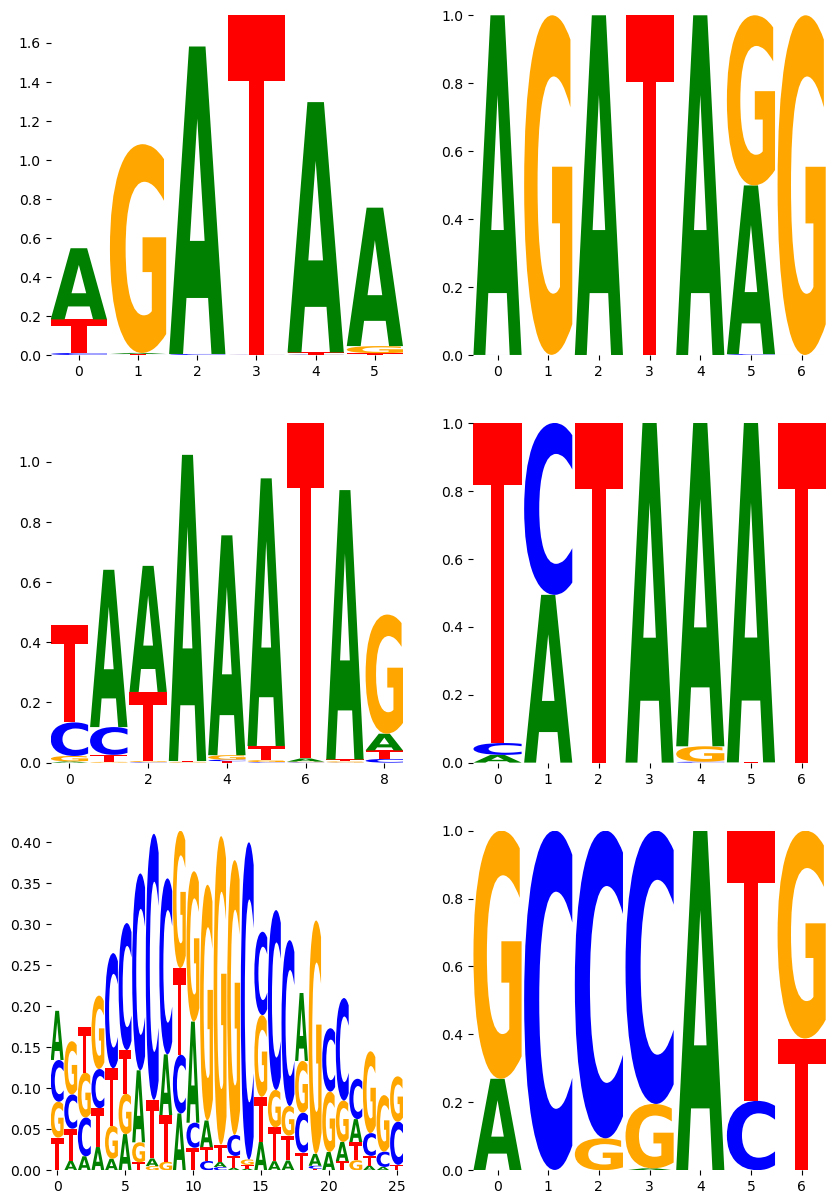

In [36]:
%matplotlib inline
topn=3
fig,ax = plt.subplots(nrows=topn,ncols=2,figsize=(10,topn*5))

for i,idx in enumerate(pvals.argmin(axis=1)):
    if i == topn:
        break
    plot_logo(patterns[i],ax=ax[i,0])
    plot_logo(conv1_kernelweights_softmaxxed_list[idx],ax=ax[i,1])
    

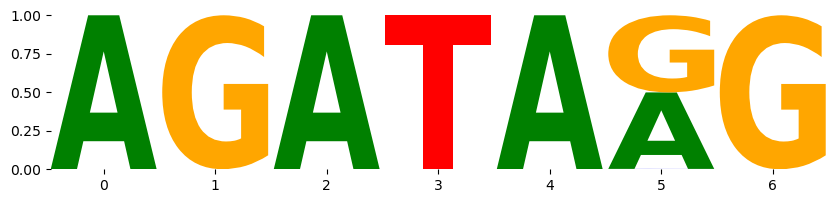

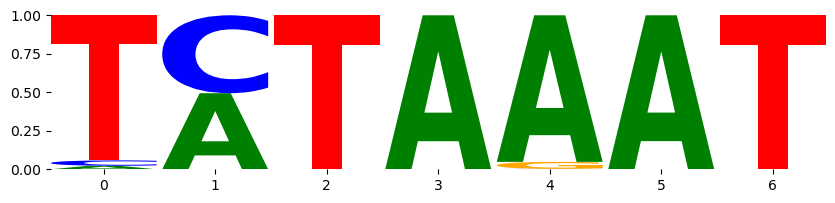

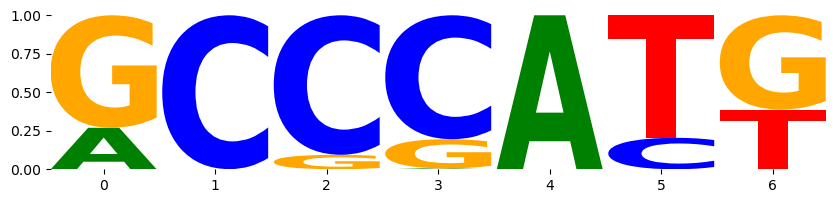

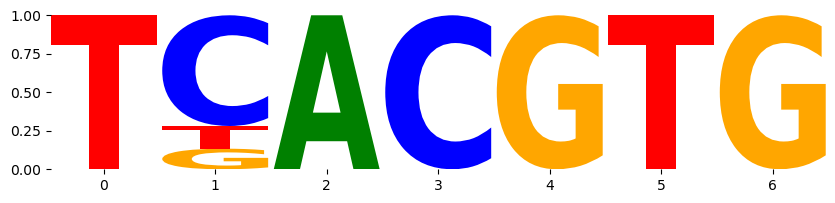

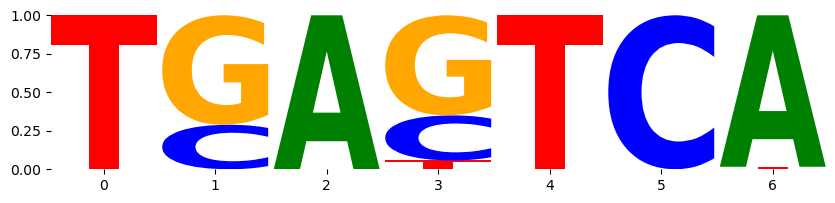

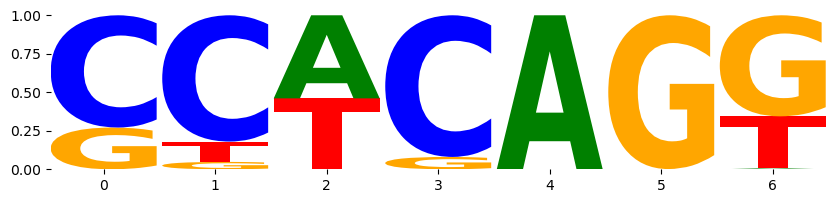

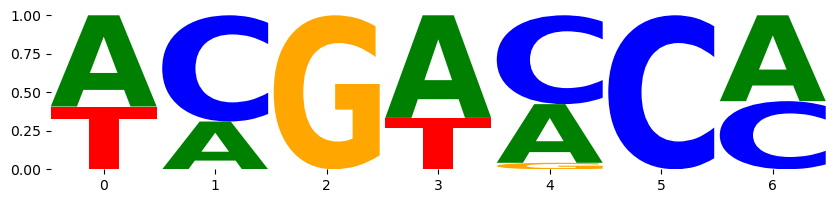

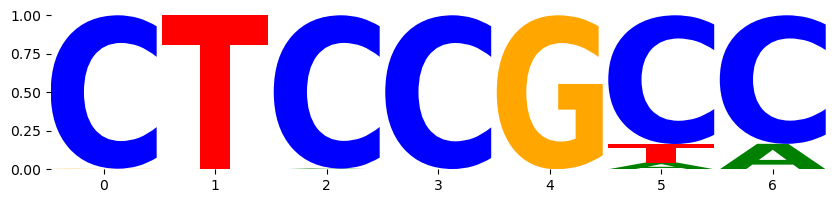

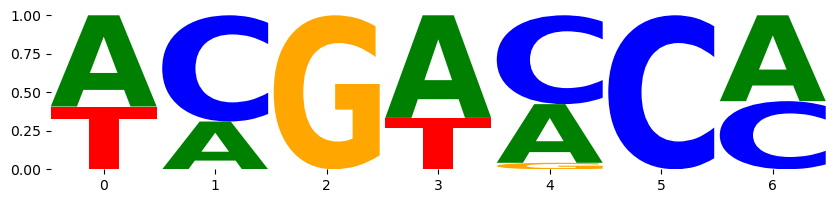

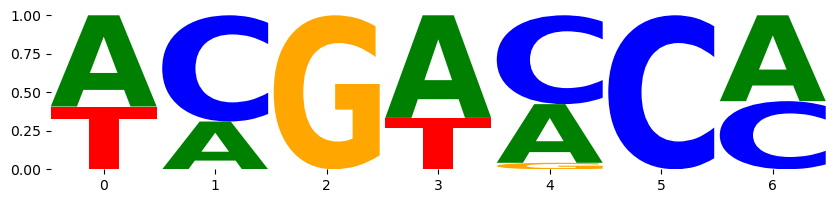

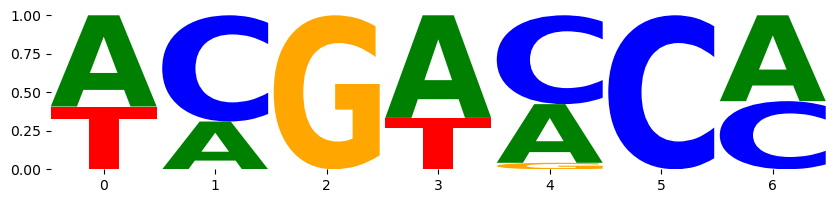

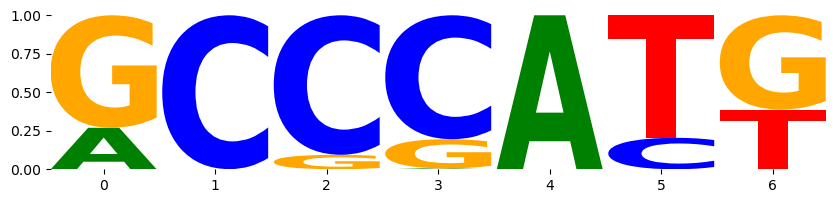

In [79]:

kernel_igm_savedir = f"{results_dir}/kernel_img/"
os.makedirs(kernel_igm_savedir, exist_ok=True)

img_filenames = []
kernelnames = []
q_vals = []

for i,idx in enumerate(pvals.argmin(axis=1)):

    fig,ax = plt.subplots(figsize=(10,2))
    plot_logo(conv1_kernelweights_softmaxxed_list[idx],ax=ax)
    fig.savefig(f"{kernel_igm_savedir}/kernel_{idx}_{df['pattern'].iloc[i]}.png",bbox_inches="tight")
    
    img_filenames.append(f"./kernel_img/kernel_{idx}_{df['pattern'].iloc[i]}.png")
    kernelnames.append(f"kernel_{idx}")
    q_vals.append(f"{pcorr[i,idx]:.5f}")
    



In [71]:
df["kernel_nr"] = kernelnames
df["kernel_match_qval"]  = q_vals
df["kernel_pattern"] = img_filenames

/tmp/ipykernel_63946/3139747259.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["kernel_nr"] = kernelnames
/tmp/ipykernel_63946/3139747259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["kernel_match_qval"]  = q_vals
/tmp/ipykernel_63946/3139747259.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [68]:
df_to_html_kernels(df,"motifs_signhits",results_dir)

In [80]:
tn5_meme_file = "/groups/stark/shenzhi.chen/projects/mouse_enhancer_paper/1st_revision/res/chromBPnet_bias_models/tn5.motifs.meme.txt"

In [17]:
from tangermeme.io import read_meme

In [118]:

tn5_motifs = read_meme(tn5_meme_file)

In [120]:
tn5_names = list(tn5_motifs.keys())
#tn5_patterns = [softmax(tn5_motifs[tn]*t) for tn in tn5_names]
tn5_patterns = [tn5_motifs[tn] for tn in tn5_names]


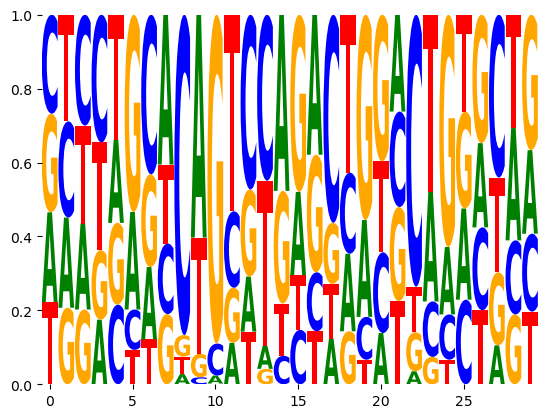

In [117]:
fig,ax = plt.subplots()
plot_logo(tn5_motifs['TN5_8'], ax=ax)

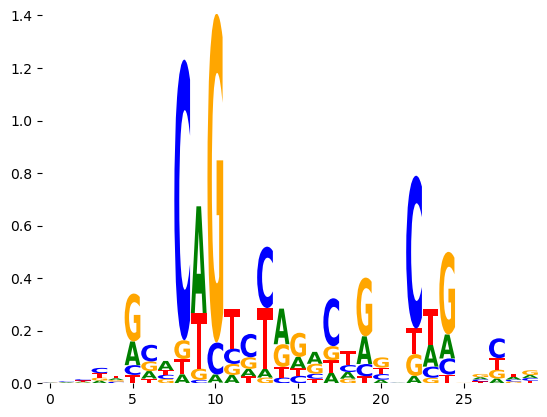

In [183]:
fig,ax = plt.subplots()
#plot_logo(compute_per_position_ic(tn5_motifs['TN5_8'],background), ax=ax)
plot_logo(ic_transform(tn5_motifs['TN5_8'],background), ax=ax)


In [121]:
tomtom_matches_tn5 = tomtom(patterns,tn5_patterns, n_target_bins=None)
pvals_tn5,_,_,_,_ = tomtom_matches_tn5

pcorr_tn5 = np.ones_like(pvals_tn5)
for i,row in enumerate(pvals_tn5):
    row_corr = false_discovery_control(row)
    pcorr_tn5[i,:]=row_corr

In [181]:
background=[0.25, 0.25, 0.25, 0.25]
def ic_transform(ppm, background, pseudocount=0.001):
    ppm=np.array(ppm.T)
    alphabet_len = len(background)
    ic = ((np.log((ppm+pseudocount)/(1 + pseudocount*alphabet_len))/np.log(2))
          *ppm - (np.log(background)*background/np.log(2))[None,:])

    return (np.sum(ic,axis=1).reshape(-1,1) * ppm).T

In [156]:
ic = ((np.log((ppm+pseudocount)/(1 + pseudocount*alphabet_len))/np.log(2))
          *ppm - (np.log(background)*background/np.log(2))[None,:])

In [160]:
ic = compute_per_position_ic(tn5_motifs['TN5_8'],background)

In [178]:
ictr = compute_per_position_ic(tn5_motifs['TN5_8'], background, pseudocount=0.001)

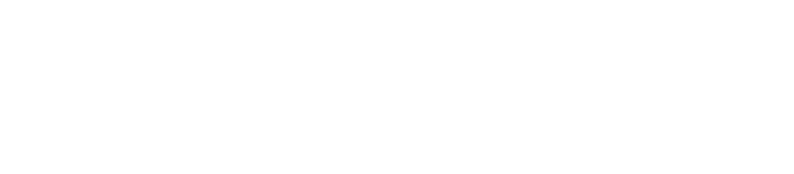

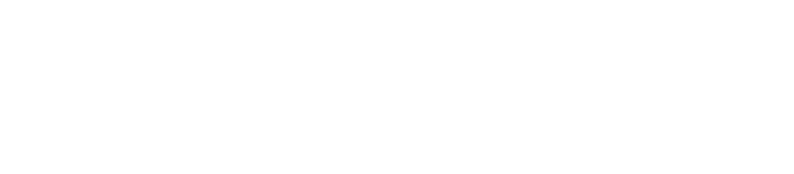

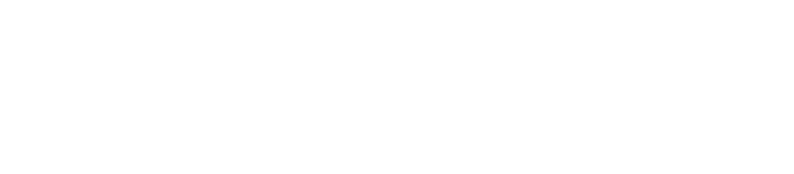

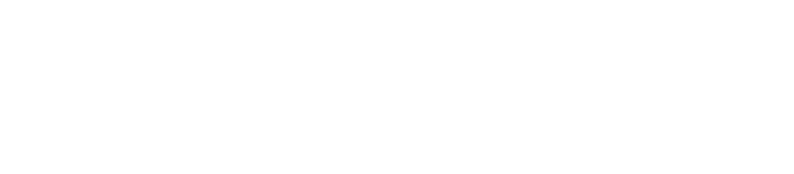

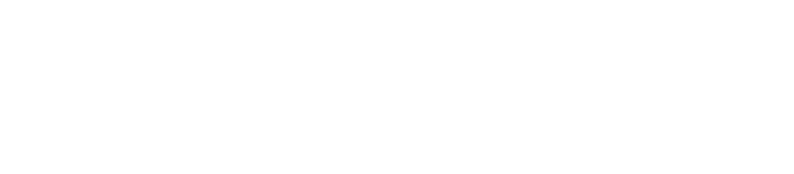

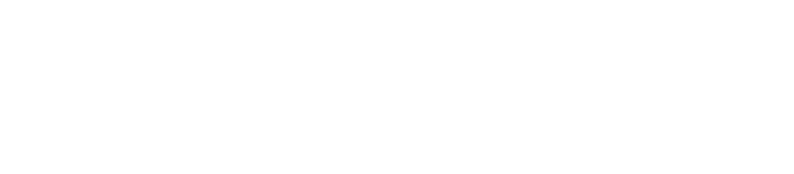

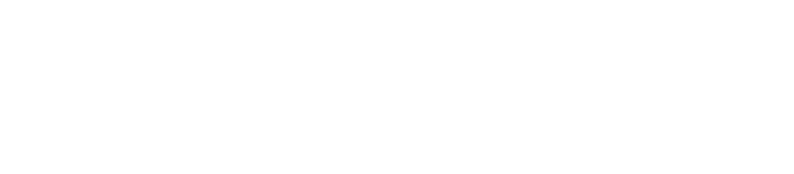

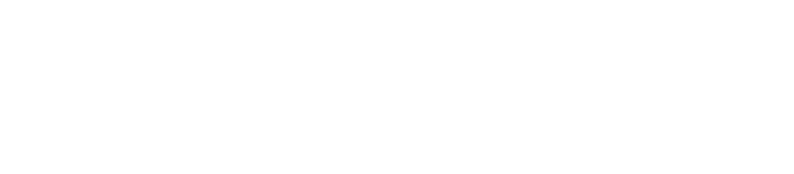

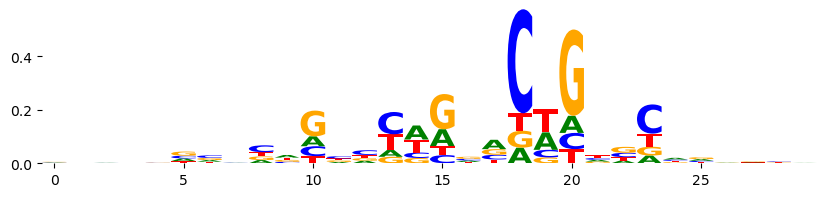

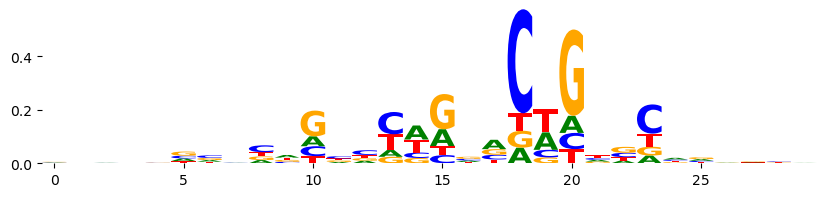

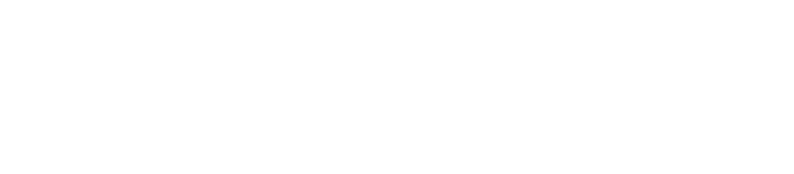

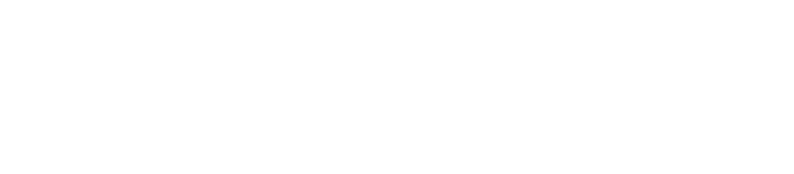

In [184]:
tn5_igm_savedir = f"{results_dir}/tn5_patterns/"
os.makedirs(tn5_igm_savedir, exist_ok=True)

q_thresh=0.01

img_filenames_tn5 = []
tn5_match_names = []
q_vals_tn5 = []

for i,idx in enumerate(pvals_tn5.argmin(axis=1)):
    
    q=pcorr_tn5[i,idx]
    fig,ax = plt.subplots(figsize=(10,2))
    
    if q<q_thresh:
        plot_logo(ic_transform(tn5_patterns[idx],background),ax=ax)
    else:
        ax.axis('off')
        
    tn5_name = tn5_names[idx]
    
    fig.savefig(f"{tn5_igm_savedir}/{tn5_name}_{df['pattern'].iloc[i]}.png",bbox_inches="tight")
    

    img_filenames_tn5.append(f"./tn5_patterns/{tn5_name}_{df['pattern'].iloc[i]}.png")
    tn5_match_names.append(tn5_name)
    q_vals_tn5.append(f"{q:.5f}")

In [185]:
df["tn5_version"] = tn5_match_names
df["Tn5_match_qval"]  = q_vals_tn5
df["Tn5_pattern"] = img_filenames_tn5

/tmp/ipykernel_63946/229690658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tn5_version"] = tn5_match_names
/tmp/ipykernel_63946/229690658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Tn5_match_qval"]  = q_vals_tn5
/tmp/ipykernel_63946/229690658.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [114]:
df_to_html_tn5(df,"motifs_signhits",results_dir)

In [40]:
!head -n 40 /groups/stark/nikolaus.mandlburger/Projects/blastoid_project/res/accessibility_models_and_data/TE_total/dataselection_3/feature_attributions/trainingruns_280524/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt

MEME version 4

ALPHABET= ACGT

strands: + -

Background letter frequencies
A 0.25 C 0.25 G 0.25 T 0.25

MOTIF MA0004.1 Arnt
letter-probability matrix: alength= 4 w= 6 nsites= 20 E= 0
 0.200000  0.800000  0.000000  0.000000
 0.950000  0.000000  0.050000  0.000000
 0.000000  1.000000  0.000000  0.000000
 0.000000  0.000000  1.000000  0.000000
 0.000000  0.000000  0.000000  1.000000
 0.000000  0.000000  1.000000  0.000000
URL http://jaspar.genereg.net/matrix/MA0004.1

MOTIF MA0069.1 PAX6
letter-probability matrix: alength= 4 w= 14 nsites= 43 E= 0
 0.046512  0.093023  0.093023  0.767442
 0.046512  0.046512  0.000000  0.906977
 0.093023  0.604651  0.023256  0.279070
 0.906977  0.046512  0.023256  0.023256
 0.069767  0.790698  0.023256  0.116279
 0.023256  0.000000  0.953488  0.023256
 0.023256  0.860465  0.093023  0.023256
 0.488372  0.046512  0.046512  0.418605
 0.023256  0.093023  0.023256  0.860465
 0.046512  0.325581  0.581395  0.046512
 0.837209  0.000000  0.139535  0.023256
 0.255814

In [ ]:

from tangermeme.utils import one_hot_encode

jaspar_file="/groups/stark/nikolaus.mandlburger/Projects/blastoid_project/res/accessibility_models_and_data/TE_total/dataselection_3/feature_attributions/trainingruns_280524/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt"
motif_dict = read_meme(jaspar_file)

motif_pwms = []
motif_names = []

for k,v in motif_dict.items():
    motif_names.append(k)
    motif_pwms.append(v)
    
pattern = one_hot_encode("TTAACAGC")
tomtom_matches = tomtom([pattern],motif_pwms, n_target_bins=None)
pvals,scores,_,_,idxs = tomtom_matches
motif_names[pvals.argmin()]